In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from tensorflow.keras.datasets import fashion_mnist

In [4]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
train_images.shape

(60000, 28, 28)

In [6]:
train_images.ndim

3

In [7]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

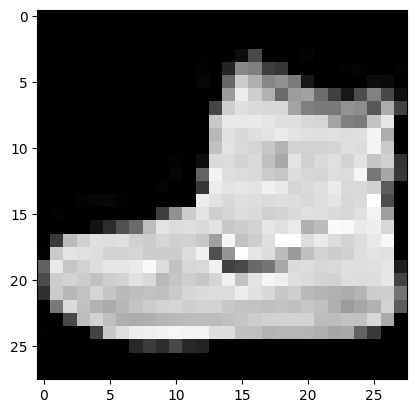

In [8]:
plt.imshow(train_images[0], cmap='gray')

In [9]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [10]:
print(class_names[train_labels[0]])

Ankle boot


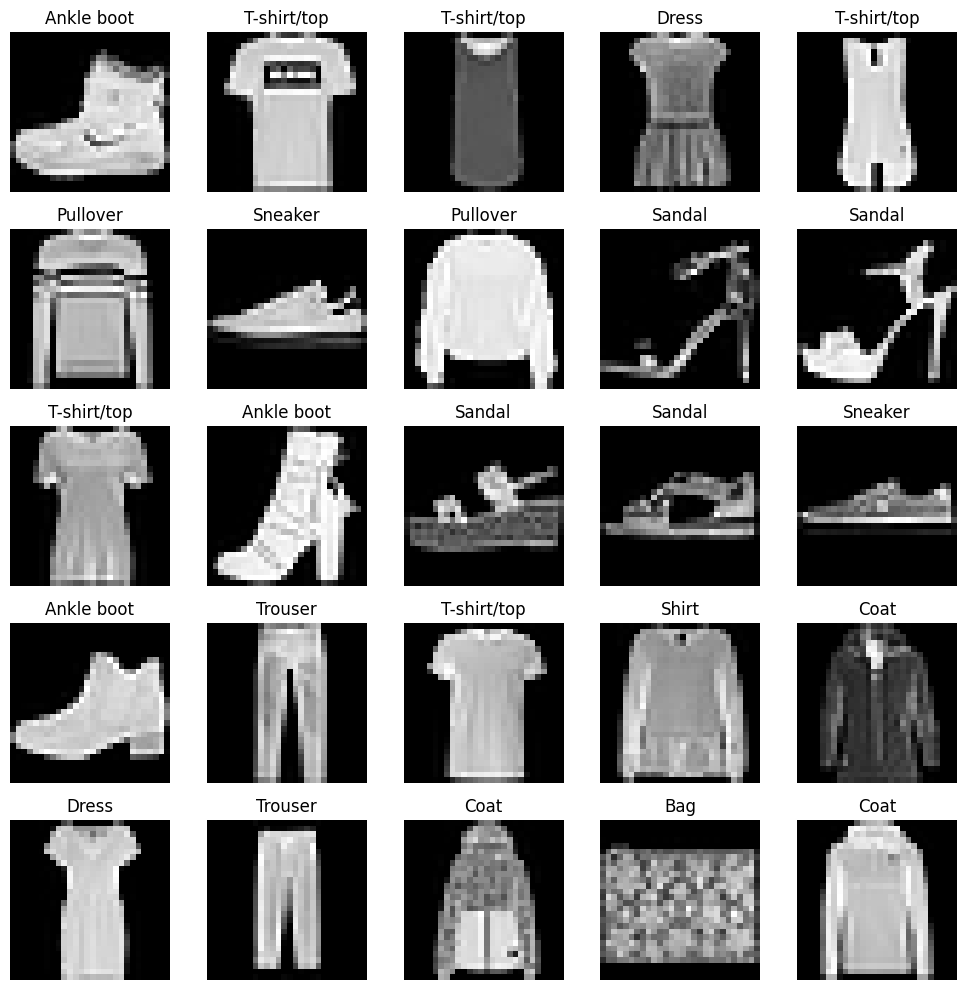

In [11]:
plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.imshow(train_images[i], cmap='gray')
  plt.title(class_names[train_labels[i]])
  plt.axis('off')
plt.tight_layout()
plt.show()

In [13]:
from tensorflow.keras.utils import to_categorical
encoded_train_labels = to_categorical(train_labels)
encoded_test_labels = to_categorical(test_labels)
print(encoded_train_labels.shape)
print(encoded_test_labels.shape)

(60000, 10)
(10000, 10)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [32]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(
    optimizer='adam',
    loss= 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [35]:
print(train_images.shape)
print(test_images.shape)

(60000, 784)
(10000, 784)


In [36]:
train_images= train_images.reshape((60000,784))
test_images= test_images.reshape((10000,784))

In [37]:
test_images.shape

(10000, 784)

In [38]:
train_images = train_images.astype('float32')
test_images = test_images.astype('float32')

In [39]:
train_images = train_images / 255
test_images = test_images / 255

In [40]:
history = model.fit(

    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.0976 - loss: 2.3027 - val_accuracy: 0.0942 - val_loss: 2.3026
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.0996 - loss: 2.3026 - val_accuracy: 0.0942 - val_loss: 2.3027
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.1081 - loss: 2.3022 - val_accuracy: 0.0925 - val_loss: 2.3019
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.1128 - loss: 2.3010 - val_accuracy: 0.0942 - val_loss: 2.2999
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.1266 - loss: 2.2984 - val_accuracy: 0.0952 - val_loss: 2.2967
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.1596 - loss: 2.2937 - val_accuracy: 0.1435 - val_loss: 2.2909
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.1963 - loss: 2.2868 - val_accuracy: 0.0952 - val_loss: 2.2840
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.1952 - loss: 2.2776 - val_accu

In [26]:
print(train_images.shape)
print(test_images.shape)

(60000, 28, 28)
(10000, 784)
